# Level 1 - Task 2: City Analysis

## Objective

The objective of this task is to analyze restaurant distribution across different cities.

### The task includes:

- Identify the city with the highest number of restaurants.
- Calculate the average restaurant rating for each city.
- Determine the city with the highest average rating.
- Visualize the findings using bar charts.

### Libraries Used

- Pandas
- Matplotlib
- Seaborn

## Step 1: Count Restaurants in Each City

This step identifies how many restaurants are present in each city.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [4]:
df = pd.read_csv("../Dataset.csv")

In [5]:
# Verify the dataset loaded correctly
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [6]:
# Count restaurants in each city
city_counts = df["City"].value_counts()

# Display top 10 cities
city_counts.head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Ahmedabad         21
Lucknow           21
Guwahati          21
Name: count, dtype: int64

## Step 2: Identify the City with the Highest Number of Restaurants

The city with the maximum number of restaurants is identified using the restaurant count.

In [8]:
# City with highest number of restaurants
top_city = city_counts.idxmax()
top_city_count = city_counts.max()

print("City with Highest Number of Restaurants:", top_city)
print("Number of Restaurants:", top_city_count)

City with Highest Number of Restaurants: New Delhi
Number of Restaurants: 5473


## Step 3: Calculate the Average Rating for Each City

The restaurants are grouped by city, and the average aggregate rating is calculated.

In [10]:
city_ratings = df.groupby("City")["Aggregate rating"].mean().sort_values(ascending=False)

city_ratings.head(10)

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Tagaytay City       4.500000
Secunderabad        4.500000
Name: Aggregate rating, dtype: float64

## Step 4: Analyze Average Ratings for Cities with at Least 10 Restaurants

Some cities have only a few restaurants, which can result in misleading average ratings.

To make the analysis more reliable, we consider only cities that have at least 10 restaurants.

In [12]:
# Calculate restaurant count and average rating for each city
city_stats = df.groupby("City").agg({
    "Restaurant ID": "count",
    "Aggregate rating": "mean"
})

# Rename columns
city_stats.columns = ["Restaurant Count", "Average Rating"]

# Filter cities with at least 10 restaurants
city_stats = city_stats[city_stats["Restaurant Count"] >= 10]

# Sort by average rating
city_stats = city_stats.sort_values(by="Average Rating", ascending=False)

city_stats.head(10)

,Restaurant Count,Average Rating
City,,
London,20,4.535000
Orlando,20,4.475000
Tampa Bay,20,4.410000
Rest of Hawaii,20,4.410000
Bangalore,20,4.375000
Dubai,20,4.370000
Jakarta,16,4.356250
Hyderabad,18,4.344444
Chennai,20,4.315000


## Step 5: Visualize the Top 10 Cities by Average Rating

The following bar chart compares the average ratings of the top 10 cities with at least 10 restaurants.

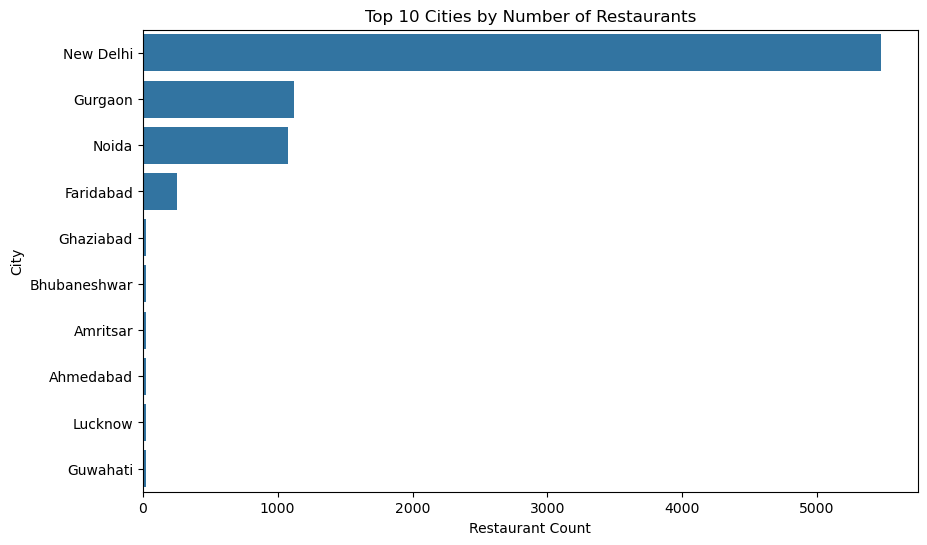

In [14]:
import os

os.makedirs("../images", exist_ok=True)

summary = pd.DataFrame({
    "City": city_counts.head(10).index,
    "Restaurant Count": city_counts.head(10).values
})

plt.figure(figsize=(10,6))

sns.barplot(
    data=summary,
    x="Restaurant Count",
    y="City"
)

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("Restaurant Count")
plt.ylabel("City")

plt.savefig(
    "../images/city_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Conclusion

## Key Findings

- New Delhi has the highest number of restaurants in the dataset.
- Average ratings were calculated for each city.
- To ensure a fair comparison, only cities with at least 10 restaurants were considered.
- The visualization highlights the top-performing cities based on average restaurant ratings.

This analysis provides useful insights into restaurant distribution and customer satisfaction across different cities.